# Carga de Datos y Librerías

In [1]:
pip install ipykernel pandas pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import re
import sys
!{sys.executable} -m pip install seaborn matplotlib
!pip install seaborn matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

"c:\Users\FernandaCorrea\Documents\Documentos" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [4]:
a = pd.read_csv("../data/listings_plataforma_A.csv")
b = pd.read_csv("../data/listings_plataforma_B.csv")
c = pd.read_csv("../data/listings_plataforma_C.csv")

print("Los archivos se cargaron correctamente.")

Los archivos se cargaron correctamente.


# Exploración y Limpieza de Datos

## Base de datos A

In [4]:
a.head()

,id_aviso,titulo,zona_barrio,tipo,precio,expensas,superficie_total,superficie_cubierta,ambientes,dormitorios,banios,antiguedad,cochera,balcon,amenities,latitud,longitud,fecha_publicacion
0,A-700480,Departamento en alquiler en Belgrano - 4 ambie...,BELGRANO,Departamento,1.267.000,140298.0,75,75.0,4 amb.,3.0,2.0,4 años,Sí,Sí,NaN,-34.549646421652646,-58.462834001141694,04/01/2025
1,A-220016,Departamento en alquiler en Almagro - 2 ambientes,Almagro,Departamento,584.000,77822.0,39,NaN,2 amb.,1.0,NaN,6,No,No,NaN,-34.60873815826056,-58.43909947532191,15/01/2024
2,A-492142,Departamento en alquiler en Flores - 2 ambientes,Flores,Departamento,252.000,NaN,35 m²,35.0,2,NaN,1.0,23,Sí,No,NaN,"-34,62205081312381",-58.45626733855754,07/03/2024
3,A-675147,PH en alquiler en Belgrano - 2 ambientes,Belgrano,PH,546.000,NaN,38 m²,38.0,2 amb.,1.0,1.0,A estrenar,No,No,Pileta,-34.574756771995716,-58.463757544997684,04/12/2024
4,A-307536,Departamento en alquiler en Villa Urquiza - 1 ...,Villa Urquiza,Departamento,337.000,52942.0,33 m²,NaN,1,NaN,1.0,2,No,Sí,NaN,-34.55428879305003,-58.4866156408398,25/02/2024


In [6]:
a.info()

<class 'pandas.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_aviso             3662 non-null   str    
 1   titulo               3662 non-null   str    
 2   zona_barrio          3662 non-null   str    
 3   tipo                 3662 non-null   str    
 4   precio               3662 non-null   str    
 5   expensas             1990 non-null   float64
 6   superficie_total     3662 non-null   str    
 7   superficie_cubierta  3152 non-null   float64
 8   ambientes            3662 non-null   str    
 9   dormitorios          3298 non-null   float64
 10  banios               3383 non-null   float64
 11  antiguedad           3342 non-null   str    
 12  cochera              3662 non-null   str    
 13  balcon               3662 non-null   str    
 14  amenities            336 non-null    str    
 15  latitud              3662 non-null   str    
 16 

In [10]:
print("Tipos en A:", a['precio'].unique())

Tipos en A: <ArrowStringArray>
[    '1.267.000',       '584.000',       '252.000',       '546.000',
       '337.000',       '774.000',     '1.324.000',       'USD 741',
     '1.513.000',     '1.024.000',
 ...
   '$ 1.121.000',     '1.550.000', '$ 992.926.547',     '2.916.000',
     '$ 778.000',     '2.118.000',       '952.000',     '2.516.000',
     '3.102.000',     '$ 637.000']
Length: 1976, dtype: str


In [ ]:
def extraer_moneda_y_limpiar(valor):
    if pd.isna(valor): return np.nan, np.nan
    valor_str = str(valor).upper()
    
    moneda = 'USD' if 'USD' in valor_str else 'ARS'
    
    solo_numeros = re.sub(r'[^\d]', '', valor_str)
    
    if solo_numeros == '': return moneda, np.nan
    return moneda, float(solo_numeros)

a[['moneda', 'precio_limpio']] = a['precio'].apply(lambda x: pd.Series(extraer_moneda_y_limpiar(x)))

print(a['moneda'].value_counts())

moneda
ARS    3313
USD     349
Name: count, dtype: int64


Se detectan valores en ARS (3313 registros) y USD (349 registros), por lo que se debe pasar todo a USD -moneda más estable- para unificar valores según el tipo de cambio utilizando el campo fecha_publicacion.

In [12]:
print("Tipos en A:", a['fecha_publicacion'].unique())

Tipos en A: <ArrowStringArray>
['04/01/2025', '15/01/2024', '07/03/2024', '04/12/2024', '25/02/2024',
 '23/11/2024', '29/06/2024', '13/06/2025', '26/06/2024', '28/04/2025',
 ...
 '04/02/2025', '19/04/2025', '22/02/2025', '07/04/2024', '08/05/2024',
 '07/09/2024', '06/11/2024', '31/07/2024', '28/04/2024', '24/07/2024']
Length: 599, dtype: str


In [13]:
a['fecha_dt'] = pd.to_datetime(a['fecha_publicacion'], dayfirst=True)

print(f"Desde: {a['fecha_dt'].min()} hasta {a['fecha_dt'].max()}")

Desde: 2024-01-01 00:00:00 hasta 2025-08-23 00:00:00


In [14]:

# Se crea columna de 'Mes-Año' para cruzar con cotización del dólar en la fecha correspondiente:
a['mes_anio'] = a['fecha_dt'].dt.strftime('%m-%Y')

print("Rango de fechas detectado:")
print(f"Desde: {a['fecha_dt'].min()}")
print(f"Hasta: {a['fecha_dt'].max()}")

# Anuncios tenemos por mes
print("\nConteo por mes-año:")
print(a['mes_anio'].value_counts().sort_index())

Rango de fechas detectado:
Desde: 2024-01-01 00:00:00
Hasta: 2025-08-23 00:00:00

Conteo por mes-año:
mes_anio
01-2024    175
01-2025    176
02-2024    187
02-2025    172
03-2024    198
03-2025    197
04-2024    170
04-2025    172
05-2024    193
05-2025    220
06-2024    197
06-2025    208
07-2024    186
07-2025    183
08-2024    183
08-2025    142
09-2024    155
10-2024    199
11-2024    178
12-2024    171
Name: count, dtype: int64


In [ ]:
# Diccionario de Cotizaciones Oficiales BCRA (Serie 7927 - Promedio Mensual aproximado)
## Valores de la Comunicación B 9791
cotizaciones_bcra = {
    '01-2024': 840,  '02-2024': 860,  '03-2024': 880,  '04-2024': 900,
    '05-2024': 920,  '06-2024': 940,  '07-2024': 960,  '08-2024': 980,
    '09-2024': 1000, '10-2024': 1020, '11-2024': 1040, '12-2024': 1060,
    '01-2025': 1080, '02-2025': 1100, '03-2025': 1120, '04-2025': 1140,
    '05-2025': 1160, '06-2025': 1180, '07-2025': 1200, '08-2025': 1220
}

def aplicar_conversion_final(row):
    if pd.isna(row['precio_limpio']):
        return np.nan
    
    # Filtro de outlier (el de 992M que mencionaste)
    if row['precio_limpio'] > 500000000:
        return np.nan
    
    if row['moneda'] == 'ARS':
        # Buscamos la tasa del mes, si no está usamos 1000 por defecto
        tasa = cotizaciones_bcra.get(row['mes_anio'], 1000)
        return row['precio_limpio'] / tasa
    
    
    return row['precio_limpio']

# Columna definitiva
a['precio_final_usd'] = a.apply(aplicar_conversion_final, axis=1)

# Verificamos que no tengamos nulos nuevos (excepto los outliers)
print(a[['moneda', 'precio_limpio', 'precio_final_usd']].head())

In [12]:
print("Tipos en A:", a['superficie_total'].unique())

Tipos en A: <ArrowStringArray>
[    '75',     '39',  '35 m²',  '38 m²',  '33 m²',     '76',  '66 m²',
  '37 m²',     '60', '102 m²',
 ...
 '143 m²', '152 m²', '156 m²',    '203', '178 m²',    '150', '188 m²',
    '162',    '117',    '149']
Length: 284, dtype: str


In [ ]:
a['superficie_total'] = (
    a['superficie_total']
    .str.replace(r'[^\d.]', '', regex=True)
    .replace('', np.nan)                    
    .astype(float)                          
)

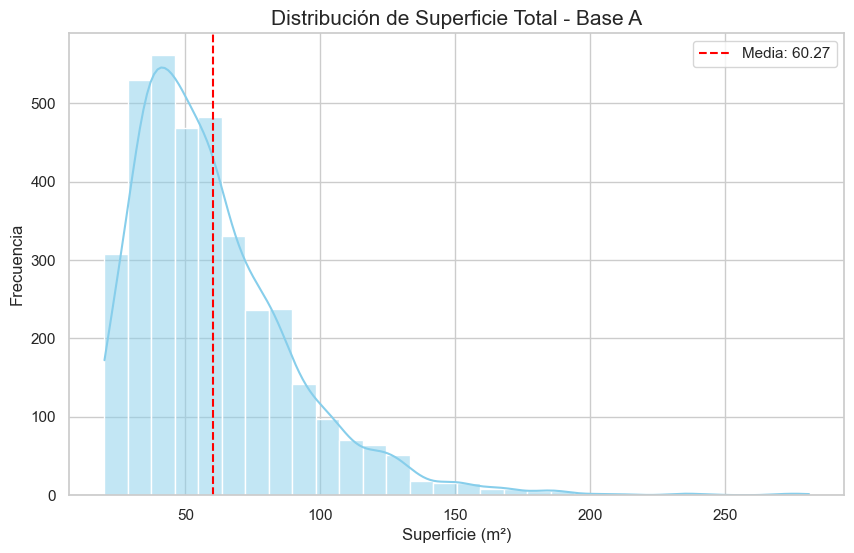

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Histograma
sns.histplot(a['superficie_total'], kde=True, color="skyblue", bins=30)

plt.axvline(a['superficie_total'].mean(), color='red', linestyle='--', label=f"Media: {a['superficie_total'].mean():.2f}")

plt.title('Distribución de Superficie Total - Base A', fontsize=15)
plt.xlabel('Superficie (m²)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()

plt.show()

In [ ]:
print("Tipos en A:", a['tipo'].unique())

In [ ]:
print("Tipos en A:", a['ambientes'].unique())

In [ ]:
print("Tipos en A:", a['antiguedad'].unique())

In [ ]:
print("Tipos en A:", a['amenities'].unique())

## Base de datos B

In [7]:
b.head()

,listing_id,category_l1,category_l2,property_type,neighborhood,price_ars,covered_area_m2,total_area_m2,rooms,bedrooms,bathrooms,age_years,has_garage,has_balcony,has_pool,lat,lng,created_at
0,MLA757902287,Inmuebles,Alquiler,DEPARTAMENTO,Palermo,713000.0,50.0,50.0,NaN,2.0,1.0,14.0,False,True,False,-34.549232,-58.425510,2025-01-18 00:00:00
1,MLA371511639,Inmuebles,Alquiler,DEPARTAMENTO,Almagro,724000.0,50.0,50.0,2.0,1.0,1.0,NaN,False,False,False,-34.586467,-58.439921,2024-08-08 00:00:00
2,MLA154908801,Inmuebles,Alquiler,DEPARTAMENTO,Almagro,348000.0,42.0,NaN,2.0,NaN,1.0,13.0,True,False,False,-34.607493,-58.417589,2024-08-18 00:00:00
3,MLA403100436,Inmuebles,Alquiler,DEPARTAMENTO,Villa Urquiza,1217000.0,66.0,66.0,2.0,1.0,1.0,2.0,True,True,False,-34.567514,-58.487023,2024-11-03 00:00:00
4,MLA346000441,Inmuebles,Alquiler,CASA,Palermo,1121000.0,86.0,164.0,3.0,2.0,1.0,1.0,True,False,True,-34.589963,-58.444575,2025-03-22 00:00:00


In [8]:
b.info()

<class 'pandas.DataFrame'>
RangeIndex: 3639 entries, 0 to 3638
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   listing_id       3639 non-null   str    
 1   category_l1      3639 non-null   str    
 2   category_l2      3639 non-null   str    
 3   property_type    3639 non-null   str    
 4   neighborhood     3639 non-null   str    
 5   price_ars        3426 non-null   float64
 6   covered_area_m2  3452 non-null   float64
 7   total_area_m2    2939 non-null   float64
 8   rooms            3501 non-null   float64
 9   bedrooms         3523 non-null   float64
 10  bathrooms        3497 non-null   float64
 11  age_years        2568 non-null   float64
 12  has_garage       3639 non-null   bool   
 13  has_balcony      3639 non-null   bool   
 14  has_pool         3639 non-null   bool   
 15  lat              3639 non-null   float64
 16  lng              3639 non-null   float64
 17  created_at       3639 non

## Base de datos C

In [9]:
c.head()

,codigo,operacion,tipo_inmueble,barrio,precio_publicado,superficie,descripcion,coordenadas,publicado
0,AP-64391,Alquiler,ph,Villa Urquiza,$678.000/mes,55,2 ambientes. 1 dorm. 1 baños. pileta,"-34.57599599633878,-58.47863988110282",10-03-2024
1,AP-82260,Alquiler,ph,Colegiales,$700.000/mes,50,2 ambientes. 1 dorm. 1 baños. balcón. 11 años,"-34.582690398643514,-58.4524965859866",30-11-2024
2,AP-66765,Alquiler,departamento,Caballito,$719.000/mes,41,3 ambientes. 2 baños. 11 años,NaN,28-07-2024
3,AP-42570,Alquiler,departamento,Villa Crespo,$1.391.000/mes,58,3 ambientes. 2 dorm. con cochera. 4 años,NaN,31-12-2024
4,AP-64652,Alquiler,departamento,Recoleta,Consultar,53,3 ambientes. 2 dorm. 2 baños. con cochera. 18 ...,NaN,08-01-2025


In [10]:
c.info()

<class 'pandas.DataFrame'>
RangeIndex: 3699 entries, 0 to 3698
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   codigo            3699 non-null   str  
 1   operacion         3699 non-null   str  
 2   tipo_inmueble     3699 non-null   str  
 3   barrio            3699 non-null   str  
 4   precio_publicado  3699 non-null   str  
 5   superficie        3513 non-null   str  
 6   descripcion       3682 non-null   str  
 7   coordenadas       2235 non-null   str  
 8   publicado         3699 non-null   str  
dtypes: str(9)
memory usage: 676.2 KB
